In [3]:
import pandas as pd

# 전국데이터
df_national = pd.read_csv("경찰청_연도별_실종아동등_가출인_접수_및_해제현황_20251231.csv", encoding="cp949")
df_national.head()

,연도,18세_미만_아동_접수,18세_미만_아동_해제,18세_미만_아동_미해제,지적자폐성정신장애인_접수,지적자폐성정신장애인_해제,지적자폐성정신장애인_미해제,치매환자_접수,치매환자_해제,치매환자_미해제,가출인(실종성인)_접수,가출인(실종성인)_해제,가출인(실종성인)_미해제
0,2021,21379,21257,1,7166,7168,4,12577,12562,9,66259,66536,261
1,2022,26416,26357,8,8344,8337,5,14527,14525,8,74936,75755,250
2,2023,25628,25516,6,8440,8434,9,14677,14654,11,74847,74827,317
3,2024,25692,25602,3,8430,8404,7,15502,15487,10,71854,71703,471
4,2025,29563,29448,67,8420,8406,31,16586,16570,15,70814,70591,765


In [4]:
# 인천데이터
df_incheon = pd.read_csv("경찰청_인천광역시경찰청_아동_실종신고_현황_20251231.csv", encoding="cp949")
df_incheon.head()

,구분,중부,미추홀,남동,부평,서부,계양,강화,연수,삼산,논현
0,2025,172,291,176,270,357,174,7,320,212,274
1,2024,146,207,159,160,393,143,15,273,291,187
2,2023,138,235,153,430,518,128,18,253,340,144
3,2022,114,218,169,331,388,115,10,194,399,170
4,2021,89,242,137,278,289,74,6,192,199,118


In [5]:
# 전국: 18세 미만 아동 접수만
df_national = df_national[["연도", "18세_미만_아동_접수"]]

# 인천: 연도별 합계 계산 + 2021년 이후만 필터링
df_incheon["합계"] = df_incheon.iloc[:, 1:].sum(axis=1)
df_incheon_recent = df_incheon[df_incheon["구분"] >= 2021]
df_incheon_recent[["구분", "합계"]]

,구분,합계
0,2025,2253
1,2024,1974
2,2023,2357
3,2022,2108
4,2021,1624


In [6]:
df_national

,연도,18세_미만_아동_접수
0,2021,21379
1,2022,26416
2,2023,25628
3,2024,25692
4,2025,29563


In [7]:
df_incheon_recent[["구분", "합계"]]

,구분,합계
0,2025,2253
1,2024,1974
2,2023,2357
3,2022,2108
4,2021,1624


In [8]:
df_incheon_recent = df_incheon_recent.rename(columns={"구분": "연도"})  # 컬럼명통일

df_merged = pd.merge(df_national, df_incheon_recent[["연도", "합계"]], on="연도")
df_merged = df_merged.rename(columns={"18세_미만_아동_접수": "전국", "합계": "인천"})
df_merged["인천_비중(%)"] = (df_merged["인천"] / df_merged["전국"] * 100).round(2)
df_merged

,연도,전국,인천,인천_비중(%)
0,2021,21379,1624,7.60
1,2022,26416,2108,7.98
2,2023,25628,2357,9.20
3,2024,25692,1974,7.68
4,2025,29563,2253,7.62


In [9]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

Text(0, 0.5, '지수 (2021년=100)')

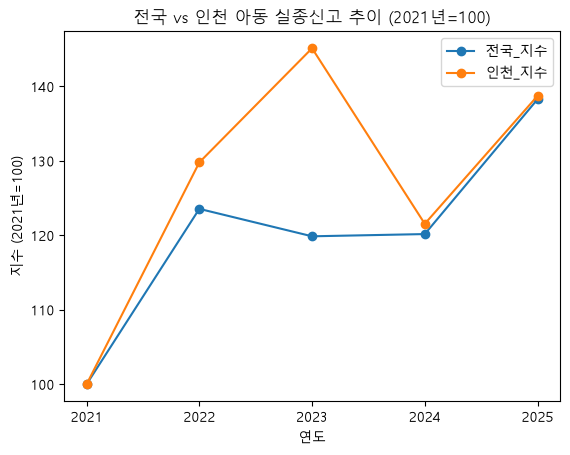

In [10]:
df_index = df_merged.copy()
df_index["전국_지수"] = df_index["전국"] / df_index["전국"].iloc[0] * 100
df_index["인천_지수"] = df_index["인천"] / df_index["인천"].iloc[0] * 100

df_index.plot(x="연도", y=["전국_지수", "인천_지수"], marker="o",
              title="전국 vs 인천 아동 실종신고 추이 (2021년=100)")
plt.xticks(df_index["연도"])
plt.ylabel("지수 (2021년=100)")

In [11]:
df_incheon_pop = pd.DataFrame({
    "연도": [2021, 2022, 2023, 2024, 2025],
    "인구": [2948375, 2967314, 2997410, 3021010, 3051961]
})

df_part2 = pd.merge(df_merged[["연도", "인천"]], df_incheon_pop, on="연도")
df_part2["실종신고_증감률(%)"] = (df_part2["인천"].pct_change() * 100).round(2)
df_part2["인구_증감률(%)"] = (df_part2["인구"].pct_change() * 100).round(2)
df_part2

,연도,인천,인구,실종신고_증감률(%),인구_증감률(%)
0,2021,1624,2948375,NaN,NaN
1,2022,2108,2967314,29.80,0.64
2,2023,2357,2997410,11.81,1.01
3,2024,1974,3021010,-16.25,0.79
4,2025,2253,3051961,14.13,1.02


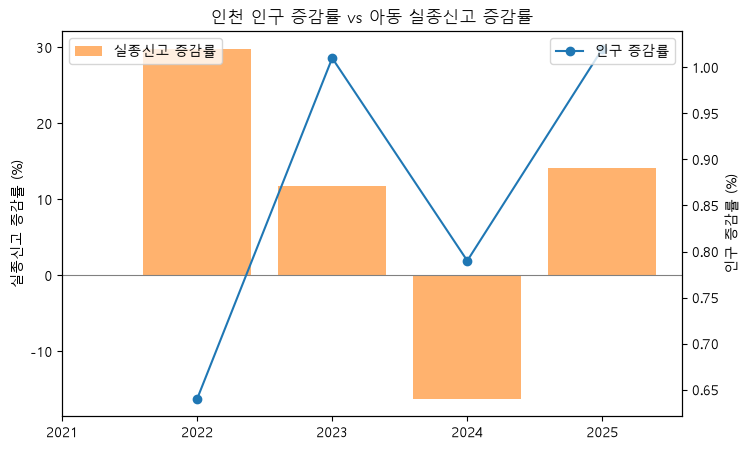

In [19]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(df_part2["연도"], df_part2["실종신고_증감률(%)"], color="tab:orange", alpha=0.6, label="실종신고 증감률")
ax1.set_ylabel("실종신고 증감률 (%)")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(df_part2["연도"], df_part2["인구_증감률(%)"], marker="o", color="tab:blue", label="인구 증감률")
ax2.set_ylabel("인구 증감률 (%)")
ax2.legend(loc="upper right")

plt.title("인천 인구 증감률 vs 아동 실종신고 증감률")
plt.xticks(df_part2["연도"]);